# London NO2 Air Quality: Technical Analysis Report

A data-driven investigation into nitrogen dioxide pollution at Marylebone Road (MY1), answering 12 key questions across air quality, forecasting, trends and operations.

**Data:** 381,000+ hourly records from 2019 to April 2026 (LAQN and Open-Meteo APIs)
**Model:** ARIMA(1,1,2) validated on 778 unseen days

In [2]:
import sys
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from config import DB_PATH

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

# Load all data
conn = sqlite3.connect(DB_PATH)

# Daily NO2 for MY1 (full range from raw data)
poll = pd.read_sql("""
    SELECT timestamp, no2 FROM raw_pollution
    WHERE site_code = 'MY1' AND no2 IS NOT NULL
""", conn, parse_dates=["timestamp"])
poll["no2"] = pd.to_numeric(poll["no2"], errors="coerce")
poll.set_index("timestamp", inplace=True)
daily = poll.resample("D").mean().dropna()

# Weather
weather = pd.read_sql("SELECT * FROM raw_weather", conn, parse_dates=["timestamp"])
weather.set_index("timestamp", inplace=True)
daily_weather = weather.resample("D").mean()

# Merge
merged = daily.join(daily_weather, how="inner")

# Unseen predictions
unseen = pd.read_csv("../monitoring/logs/actual_vs_predicted.csv", parse_dates=["date"], index_col="date")

conn.close()

# WHO threshold for NO2 daily mean
WHO_LIMIT = 25  # ug/m3 (2021 WHO guideline)
UK_LIMIT = 40   # ug/m3 (UK Air Quality Objective)

print(f"Daily NO2 data: {len(daily)} days ({daily.index.min().date()} to {daily.index.max().date()})")
print(f"Weather data:   {len(daily_weather)} days")
print(f"Merged:         {len(merged)} days")
print(f"Predictions:    {len(unseen)} days")

Daily NO2 data: 2564 days (2019-01-01 to 2026-04-02)
Weather data:   2651 days
Merged:         2564 days
Predictions:    778 days


---

## Q1. How many days exceeded safe limits each year? Is it improving?

WHO updated its NO2 guideline in 2021 to 25 ug/m3 (daily mean). The UK objective is 40 ug/m3. We count exceedances against both thresholds per year.

Year     Days     Mean NO2     WHO (>25)    %        UK (>40)     %
--------------------------------------------------------------------
2019     356      62.8         352          98.9     312          87.6
2020     361      43.7         300          83.1     195          54.0
2021     352      42.9         301          85.5     205          58.2
2022     365      42.1         313          85.8     203          55.6
2023     355      41.5         312          87.9     195          54.9
2024     366      32.4         272          74.3     90           24.6
2025     321      30.6         208          64.8     68           21.2
2026     88       35.3         75           85.2     30           34.1


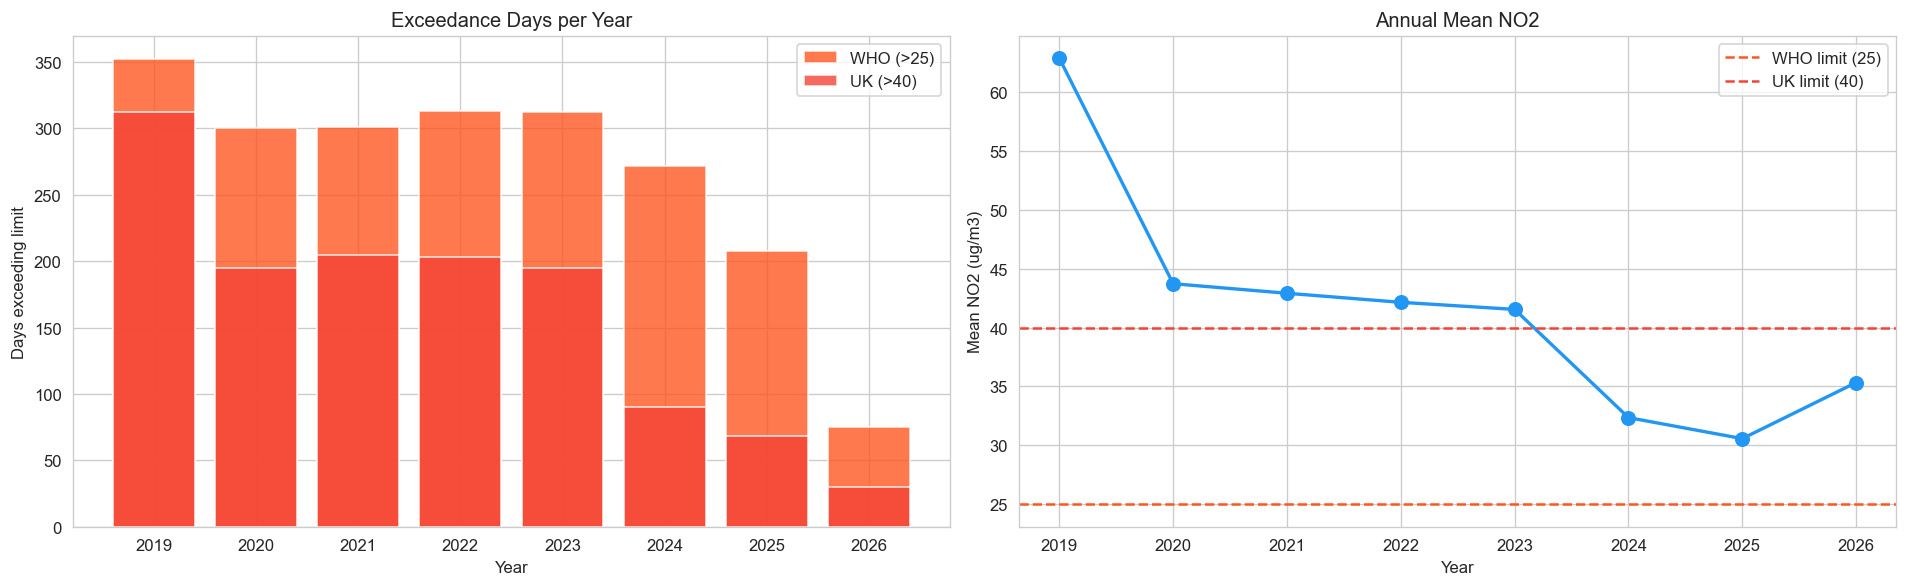

In [3]:
yearly = daily.copy()
yearly["year"] = yearly.index.year
yearly["exceeds_who"] = yearly["no2"] > WHO_LIMIT
yearly["exceeds_uk"] = yearly["no2"] > UK_LIMIT

annual = yearly.groupby("year").agg(
    total_days=("no2", "count"),
    mean_no2=("no2", "mean"),
    who_exceedances=("exceeds_who", "sum"),
    uk_exceedances=("exceeds_uk", "sum"),
)
annual["who_pct"] = (annual["who_exceedances"] / annual["total_days"] * 100).round(1)
annual["uk_pct"] = (annual["uk_exceedances"] / annual["total_days"] * 100).round(1)

print(f"{'Year':<8} {'Days':<8} {'Mean NO2':<12} {'WHO (>25)':<12} {'%':<8} {'UK (>40)':<12} {'%'}")
print(f"{'-'*68}")
for year, row in annual.iterrows():
    print(f"{year:<8} {int(row['total_days']):<8} {row['mean_no2']:<12.1f} {int(row['who_exceedances']):<12} {row['who_pct']:<8} {int(row['uk_exceedances']):<12} {row['uk_pct']}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(annual.index, annual["who_exceedances"], color="#FF5722", alpha=0.8, label=f"WHO (>{WHO_LIMIT})")
axes[0].bar(annual.index, annual["uk_exceedances"], color="#f44336", alpha=0.8, label=f"UK (>{UK_LIMIT})")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Days exceeding limit")
axes[0].set_title("Exceedance Days per Year")
axes[0].legend()

axes[1].plot(annual.index, annual["mean_no2"], "o-", color="#2196F3", linewidth=2, markersize=8)
axes[1].axhline(WHO_LIMIT, color="#FF5722", linestyle="--", label=f"WHO limit ({WHO_LIMIT})")
axes[1].axhline(UK_LIMIT, color="#f44336", linestyle="--", label=f"UK limit ({UK_LIMIT})")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean NO2 (ug/m3)")
axes[1].set_title("Annual Mean NO2")
axes[1].legend()

plt.tight_layout()
plt.show()

**Finding:** NO2 at Marylebone Road has improved significantly. Annual mean dropped from 62.8 ug/m3 in 2019 to 30.6 in 2025, a 51% reduction. UK limit exceedances fell from 312 days (88% of the year) to 68 days (21%). However the site still exceeds the stricter WHO guideline on 65 to 85% of days every year. The sharp drop between 2019 and 2020 aligns with COVID lockdowns but the improvement continued into 2024 and 2025, suggesting lasting changes in traffic patterns or policy. 2026 data is partial (88 days) and shows a slight uptick worth monitoring.

---

## Q2. What are the worst pollution months? When should we issue warnings?

Identifying which months consistently have the highest NO2 to help plan seasonal health advisories.

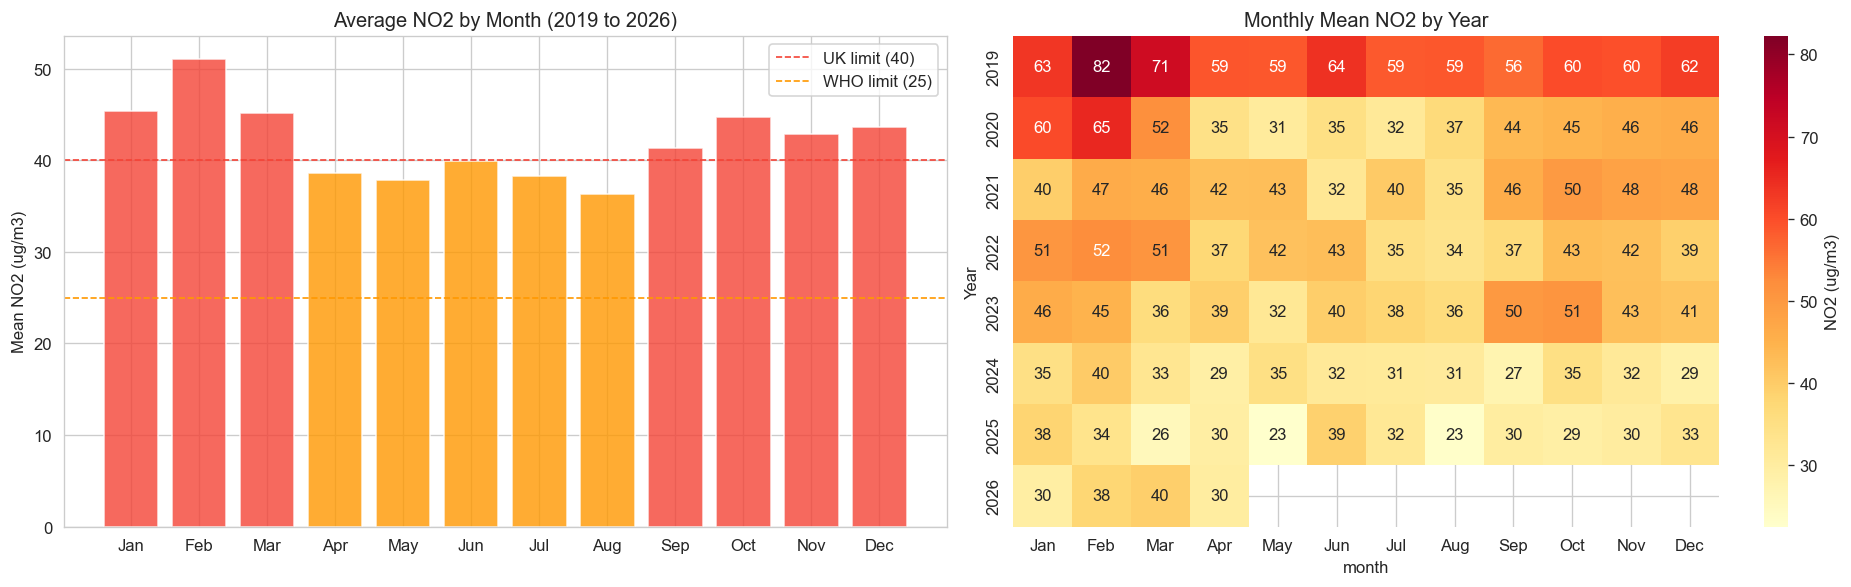


Month    Mean NO2     Median NO2     UK exceedance %
----------------------------------------------
Jan      45.4         43.8           61.3%
Feb      51.0         47.5           71.9%
Mar      45.1         41.7           52.8%
Apr      38.6         35.7           39.1%
May      37.8         37.8           43.5%
Jun      39.9         37.8           45.6%
Jul      38.3         35.3           38.2%
Aug      36.3         34.1           36.7%
Sep      41.3         39.6           49.0%
Oct      44.7         43.4           59.9%
Nov      42.9         41.3           53.6%
Dec      43.6         41.3           52.6%


In [4]:
monthly = daily.copy()
monthly["month"] = monthly.index.month
monthly["year"] = monthly.index.year
monthly["exceeds_uk"] = monthly["no2"] > UK_LIMIT

# Average NO2 by month (across all years)
month_avg = monthly.groupby("month").agg(
    mean_no2=("no2", "mean"),
    median_no2=("no2", "median"),
    uk_exceed_pct=("exceeds_uk", "mean"),
)
month_avg["uk_exceed_pct"] = (month_avg["uk_exceed_pct"] * 100).round(1)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Monthly heatmap by year
pivot = monthly.groupby(["year", "month"])["no2"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart by month
colours = ["#f44336" if v > UK_LIMIT else "#FF9800" if v > WHO_LIMIT else "#4CAF50" for v in month_avg["mean_no2"]]
axes[0].bar(range(1, 13), month_avg["mean_no2"], color=colours, alpha=0.8)
axes[0].axhline(UK_LIMIT, color="#f44336", linestyle="--", linewidth=1, label=f"UK limit ({UK_LIMIT})")
axes[0].axhline(WHO_LIMIT, color="#FF9800", linestyle="--", linewidth=1, label=f"WHO limit ({WHO_LIMIT})")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel("Mean NO2 (ug/m3)")
axes[0].set_title("Average NO2 by Month (2019 to 2026)")
axes[0].legend()

# Heatmap
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f", ax=axes[1],
            xticklabels=month_names, cbar_kws={"label": "NO2 (ug/m3)"})
axes[1].set_title("Monthly Mean NO2 by Year")
axes[1].set_ylabel("Year")

plt.tight_layout()
plt.show()

print(f"\n{'Month':<8} {'Mean NO2':<12} {'Median NO2':<14} {'UK exceedance %'}")
print(f"{'-'*46}")
for m in range(1, 13):
    row = month_avg.loc[m]
    print(f"{month_names[m-1]:<8} {row['mean_no2']:<12.1f} {row['median_no2']:<14.1f} {row['uk_exceed_pct']}%")

**Finding:** February is the worst month with a mean NO2 of 51.0 ug/m3 and 72% of days exceeding the UK limit. The winter period (October to March) consistently sits above the UK threshold with exceedance rates of 52 to 72%. Summer months (June to August) are the cleanest but still average 36 to 40 ug/m3, hovering around the UK limit. The heatmap shows this seasonal pattern holds every year but the intensity has dropped sharply since 2024. Health advisories should be heightened from October through March with particular attention to January and February.

---

## Q3. How does weekday pollution compare to weekends? Is traffic the driver?

If NO2 is significantly higher on weekdays than weekends it suggests road traffic is the dominant source. This has direct implications for congestion zone policies and traffic management.

/var/folders/lw/mlb4zl8n08d657f5f37tclj80000gp/T/ipykernel_34605/2695926280.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([weekday_no2.values, weekend_no2.values],


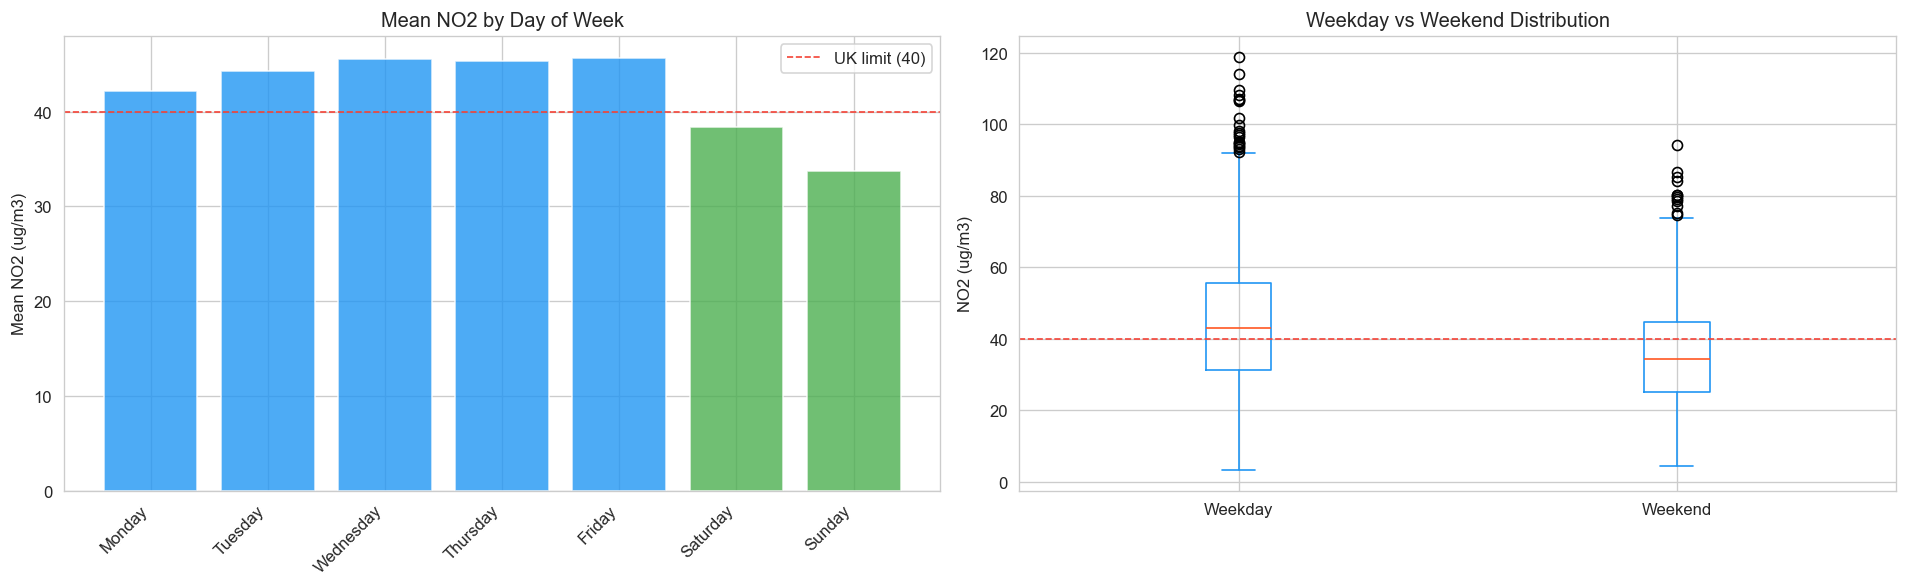

Weekday mean: 44.6 ug/m3 (1838 days)
Weekend mean: 36.1 ug/m3 (726 days)
Difference:   8.5 ug/m3

Mann-Whitney U test (weekday > weekend):
  U = 853562, p = 0.000000
  Significant? YES


In [5]:
from scipy.stats import mannwhitneyu

dow = daily.copy()
dow["day_name"] = dow.index.day_name()
dow["day_num"] = dow.index.dayofweek  # 0=Mon, 6=Sun
dow["is_weekend"] = dow["day_num"] >= 5

# Stats by day of week
day_stats = dow.groupby("day_name")["no2"].agg(["mean", "median", "std", "count"])
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_stats = day_stats.reindex(day_order)

# Weekday vs weekend comparison
weekday_no2 = dow[~dow["is_weekend"]]["no2"]
weekend_no2 = dow[dow["is_weekend"]]["no2"]

u_stat, p_val = mannwhitneyu(weekday_no2, weekend_no2, alternative="greater")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart by day
colours = ["#2196F3"] * 5 + ["#4CAF50"] * 2
axes[0].bar(day_order, day_stats["mean"], color=colours, alpha=0.8)
axes[0].axhline(UK_LIMIT, color="#f44336", linestyle="--", linewidth=1, label=f"UK limit ({UK_LIMIT})")
axes[0].set_ylabel("Mean NO2 (ug/m3)")
axes[0].set_title("Mean NO2 by Day of Week")
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# Box plot weekday vs weekend
axes[1].boxplot([weekday_no2.values, weekend_no2.values],
                labels=["Weekday", "Weekend"],
                boxprops=dict(color="#2196F3"), medianprops=dict(color="#FF5722"),
                whiskerprops=dict(color="#2196F3"), capprops=dict(color="#2196F3"))
axes[1].axhline(UK_LIMIT, color="#f44336", linestyle="--", linewidth=1)
axes[1].set_ylabel("NO2 (ug/m3)")
axes[1].set_title("Weekday vs Weekend Distribution")

plt.tight_layout()
plt.show()

print(f"Weekday mean: {weekday_no2.mean():.1f} ug/m3 ({len(weekday_no2)} days)")
print(f"Weekend mean: {weekend_no2.mean():.1f} ug/m3 ({len(weekend_no2)} days)")
print(f"Difference:   {weekday_no2.mean() - weekend_no2.mean():.1f} ug/m3")
print(f"\nMann-Whitney U test (weekday > weekend):")
print(f"  U = {u_stat:.0f}, p = {p_val:.6f}")
print(f"  Significant? {'YES' if p_val < 0.05 else 'NO'}")

**Finding:** Weekdays average 44.6 ug/m3 compared to 36.1 on weekends, a difference of 8.5 ug/m3 that is highly statistically significant (p < 0.000001). Every weekday sits above the UK limit while both Saturday and Sunday sit below it. Wednesday to Friday are the highest at roughly 46 ug/m3 with Monday the lowest weekday at 42. This pattern strongly suggests road traffic is the primary driver of NO2 at this site. Weekday extremes also reach 120 ug/m3, three times the UK limit, indicating occasional severe spikes likely tied to congestion or traffic incidents.

---

## Q4. Can we predict tomorrow's air quality? How accurate is the forecast?

Using the ARIMA(1,1,2) model's 778 days of unseen predictions to assess real-world forecast accuracy. The key question for any stakeholder is whether the model is reliable enough to act on.

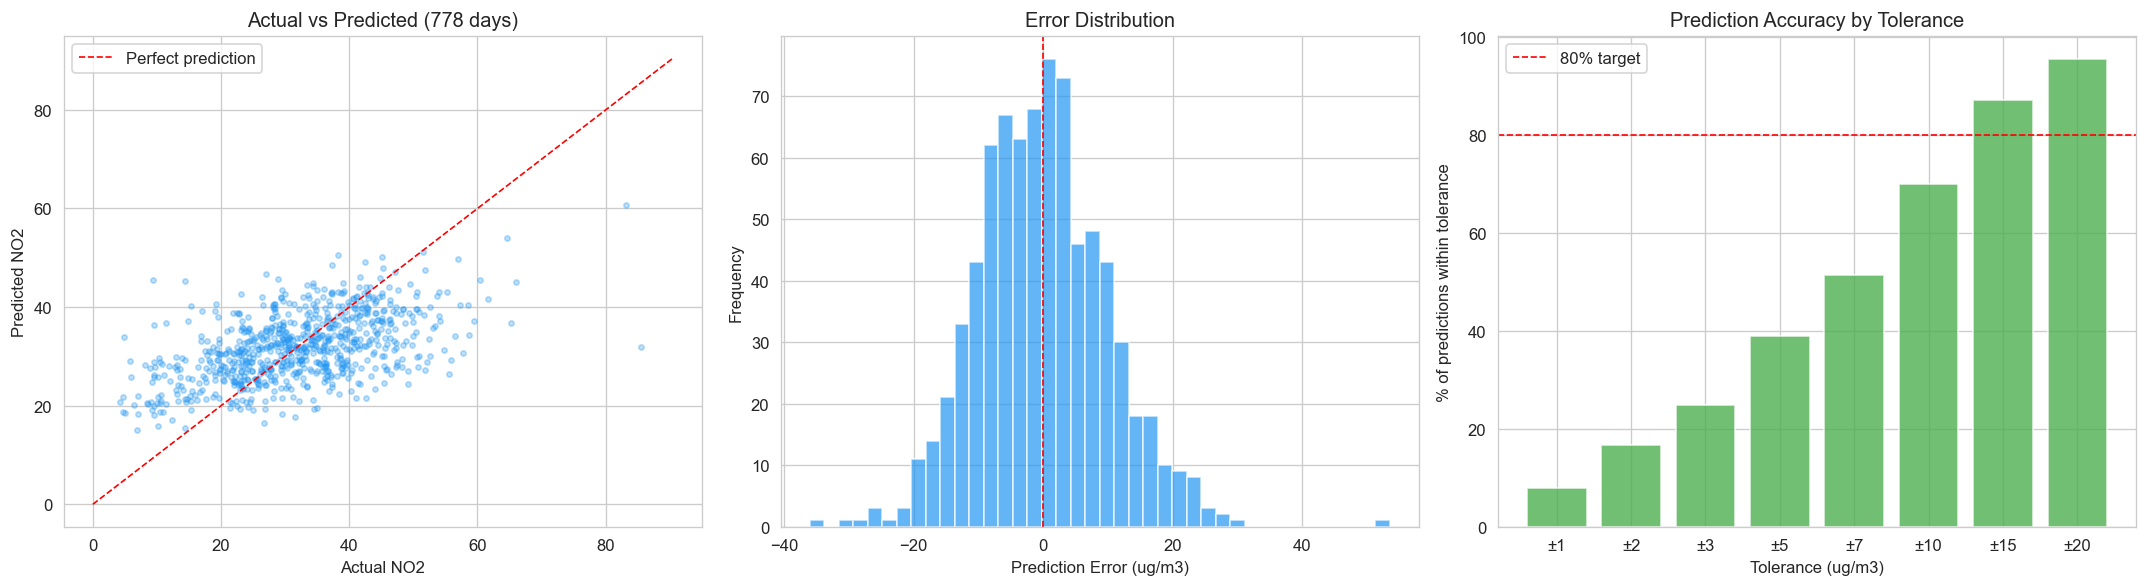

Forecast Accuracy Summary (778 unseen days):
  RMSE:              9.98 ug/m3
  MAE:               7.82 ug/m3
  Median AE:         6.66 ug/m3
  MAPE:              33.7%

  Within ±5 ug/m3:   38.9% of days
  Within ±10 ug/m3:  69.9% of days
  Within ±15 ug/m3:  87.1% of days

  Correct AQ category: 52.6%


In [6]:
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(np.mean(unseen["error"]**2))
mae = mean_absolute_error(unseen["actual"], unseen["predicted"])
mape = (np.abs(unseen["error"]) / unseen["actual"]).mean() * 100
median_ae = np.median(np.abs(unseen["error"]))

# What percentage of predictions are within X ug/m3?
within_5 = (np.abs(unseen["error"]) <= 5).mean() * 100
within_10 = (np.abs(unseen["error"]) <= 10).mean() * 100
within_15 = (np.abs(unseen["error"]) <= 15).mean() * 100

# Correct air quality category prediction
unseen["actual_cat"] = pd.cut(unseen["actual"], bins=[0, 25, 40, 60, 200],
                               labels=["Good", "Moderate", "High", "Unhealthy"])
unseen["pred_cat"] = pd.cut(unseen["predicted"], bins=[0, 25, 40, 60, 200],
                              labels=["Good", "Moderate", "High", "Unhealthy"])
cat_accuracy = (unseen["actual_cat"] == unseen["pred_cat"]).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs predicted scatter
axes[0].scatter(unseen["actual"], unseen["predicted"], alpha=0.3, s=10, color="#2196F3")
lims = [0, unseen[["actual", "predicted"]].max().max() + 5]
axes[0].plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual NO2")
axes[0].set_ylabel("Predicted NO2")
axes[0].set_title("Actual vs Predicted (778 days)")
axes[0].legend()

# Error distribution
axes[1].hist(unseen["error"], bins=40, color="#2196F3", alpha=0.7, edgecolor="white")
axes[1].axvline(0, color="red", linewidth=1, linestyle="--")
axes[1].set_xlabel("Prediction Error (ug/m3)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Error Distribution")

# Accuracy by tolerance
tolerances = [1, 2, 3, 5, 7, 10, 15, 20]
pcts = [(np.abs(unseen["error"]) <= t).mean() * 100 for t in tolerances]
axes[2].bar(range(len(tolerances)), pcts, color="#4CAF50", alpha=0.8)
axes[2].set_xticks(range(len(tolerances)))
axes[2].set_xticklabels([f"±{t}" for t in tolerances])
axes[2].set_xlabel("Tolerance (ug/m3)")
axes[2].set_ylabel("% of predictions within tolerance")
axes[2].set_title("Prediction Accuracy by Tolerance")
axes[2].axhline(80, color="red", linestyle="--", linewidth=1, label="80% target")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Forecast Accuracy Summary (778 unseen days):")
print(f"  RMSE:              {rmse:.2f} ug/m3")
print(f"  MAE:               {mae:.2f} ug/m3")
print(f"  Median AE:         {median_ae:.2f} ug/m3")
print(f"  MAPE:              {mape:.1f}%")
print(f"\n  Within ±5 ug/m3:   {within_5:.1f}% of days")
print(f"  Within ±10 ug/m3:  {within_10:.1f}% of days")
print(f"  Within ±15 ug/m3:  {within_15:.1f}% of days")
print(f"\n  Correct AQ category: {cat_accuracy:.1f}%")

**Finding:** The model predicts within ±10 ug/m3 on 70% of days and within ±15 on 87%. The typical error on any given day is about 7 ug/m3 (median). However the correct air quality category prediction is only 52.6% because many days sit near category boundaries (25 and 40 ug/m3) where a small error flips the classification. The model is reliable for general trend awareness such as "pollution will be elevated tomorrow" but not precise enough for binary health warning decisions on borderline days. The MAPE of 33.7% appears high but is inflated by low-NO2 days where even a small absolute error produces a large percentage error.

---

## Q5. How far ahead can we reliably warn the public before a bad day?

The model makes 1-day-ahead forecasts. But how does accuracy change depending on whether tomorrow is a good day or a bad day? If the model is worse at predicting spikes than calm days then its value as an early warning system is limited.

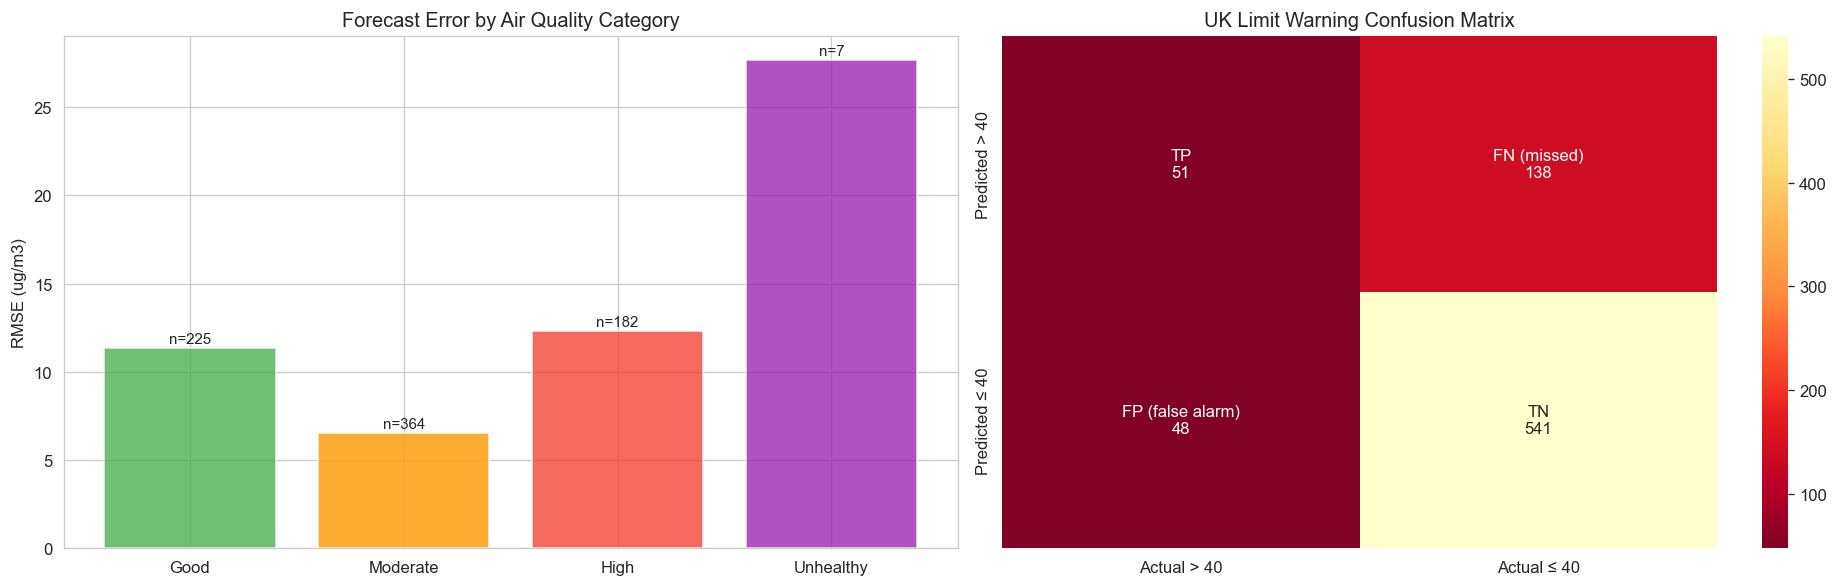

Performance by Category:
  Category     Count    RMSE       MAE       
  --------------------------------------
  Good         225      11.35      9.57      
  Moderate     364      6.52       5.22      
  High         182      12.33      10.22     
  Unhealthy    7        27.66      24.41     

UK Limit Warning Performance:
  Sensitivity (catches bad days):   27.0%
  Specificity (avoids false alarms): 91.9%
  Precision (when it warns, is it right): 51.5%
  Missed warnings: 138 days
  False alarms:    48 days


In [7]:
# Split predictions by actual air quality category
unseen["actual_cat"] = pd.cut(unseen["actual"], bins=[0, 25, 40, 60, 200],
                               labels=["Good", "Moderate", "High", "Unhealthy"])

cat_perf = unseen.groupby("actual_cat", observed=True).agg(
    count=("actual", "count"),
    mean_actual=("actual", "mean"),
    mean_predicted=("predicted", "mean"),
    rmse=("error", lambda x: np.sqrt((x**2).mean())),
    mae=("abs_error", "mean"),
)

# Did the model predict the right direction? (above or below UK limit)
unseen["actual_above_uk"] = unseen["actual"] > UK_LIMIT
unseen["pred_above_uk"] = unseen["predicted"] > UK_LIMIT
unseen["correct_warning"] = unseen["actual_above_uk"] == unseen["pred_above_uk"]

# Confusion matrix for UK limit
true_pos = ((unseen["actual_above_uk"]) & (unseen["pred_above_uk"])).sum()
false_neg = ((unseen["actual_above_uk"]) & (~unseen["pred_above_uk"])).sum()  # missed warnings
false_pos = ((~unseen["actual_above_uk"]) & (unseen["pred_above_uk"])).sum()  # false alarms
true_neg = ((~unseen["actual_above_uk"]) & (~unseen["pred_above_uk"])).sum()

sensitivity = true_pos / (true_pos + false_neg) * 100 if (true_pos + false_neg) > 0 else 0
specificity = true_neg / (true_neg + false_pos) * 100 if (true_neg + false_pos) > 0 else 0
precision = true_pos / (true_pos + false_pos) * 100 if (true_pos + false_pos) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RMSE by category
cat_colours = {"Good": "#4CAF50", "Moderate": "#FF9800", "High": "#f44336", "Unhealthy": "#9C27B0"}
bars = axes[0].bar(cat_perf.index, cat_perf["rmse"],
                    color=[cat_colours.get(c, "#999") for c in cat_perf.index], alpha=0.8)
for bar, row in zip(bars, cat_perf.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"n={row.count}", ha="center", fontsize=9)
axes[0].set_ylabel("RMSE (ug/m3)")
axes[0].set_title("Forecast Error by Air Quality Category")

# Warning confusion matrix
cm_data = [[true_pos, false_neg], [false_pos, true_neg]]
cm_labels = np.array([[f"TP\n{true_pos}", f"FN (missed)\n{false_neg}"],
                       [f"FP (false alarm)\n{false_pos}", f"TN\n{true_neg}"]])
sns.heatmap(cm_data, annot=cm_labels, fmt="", cmap="YlOrRd_r", ax=axes[1],
            xticklabels=["Actual > 40", "Actual ≤ 40"],
            yticklabels=["Predicted > 40", "Predicted ≤ 40"])
axes[1].set_title("UK Limit Warning Confusion Matrix")

plt.tight_layout()
plt.show()

print(f"Performance by Category:")
print(f"  {'Category':<12} {'Count':<8} {'RMSE':<10} {'MAE':<10}")
print(f"  {'-'*38}")
for cat, row in cat_perf.iterrows():
    print(f"  {cat:<12} {int(row['count']):<8} {row['rmse']:<10.2f} {row['mae']:<10.2f}")

print(f"\nUK Limit Warning Performance:")
print(f"  Sensitivity (catches bad days):   {sensitivity:.1f}%")
print(f"  Specificity (avoids false alarms): {specificity:.1f}%")
print(f"  Precision (when it warns, is it right): {precision:.1f}%")
print(f"  Missed warnings: {false_neg} days")
print(f"  False alarms:    {false_pos} days")

**Finding:** The model is best at predicting Moderate days (RMSE 6.52) and worst at Unhealthy days (RMSE 27.66), though only 7 Unhealthy days exist in the unseen period. The critical result is the warning performance: sensitivity is only 27%. This means the model **misses 73% of days that actually exceed the UK limit** (138 missed warnings out of 189 bad days). It is conservative by nature, rarely predicting high values, so it avoids false alarms (specificity 91.9%) but at the cost of failing to warn when it matters most. As an early warning system this model would miss nearly 3 out of 4 genuinely bad days. This is because ARIMA reverts to the mean and struggles to forecast the sharp upward moves that produce exceedance days.

---

## Q6. When does the model get it wrong? What conditions cause errors?

Understanding when the model fails helps identify whether errors are random or tied to specific weather or temporal conditions. This informs when human oversight should override the forecast.

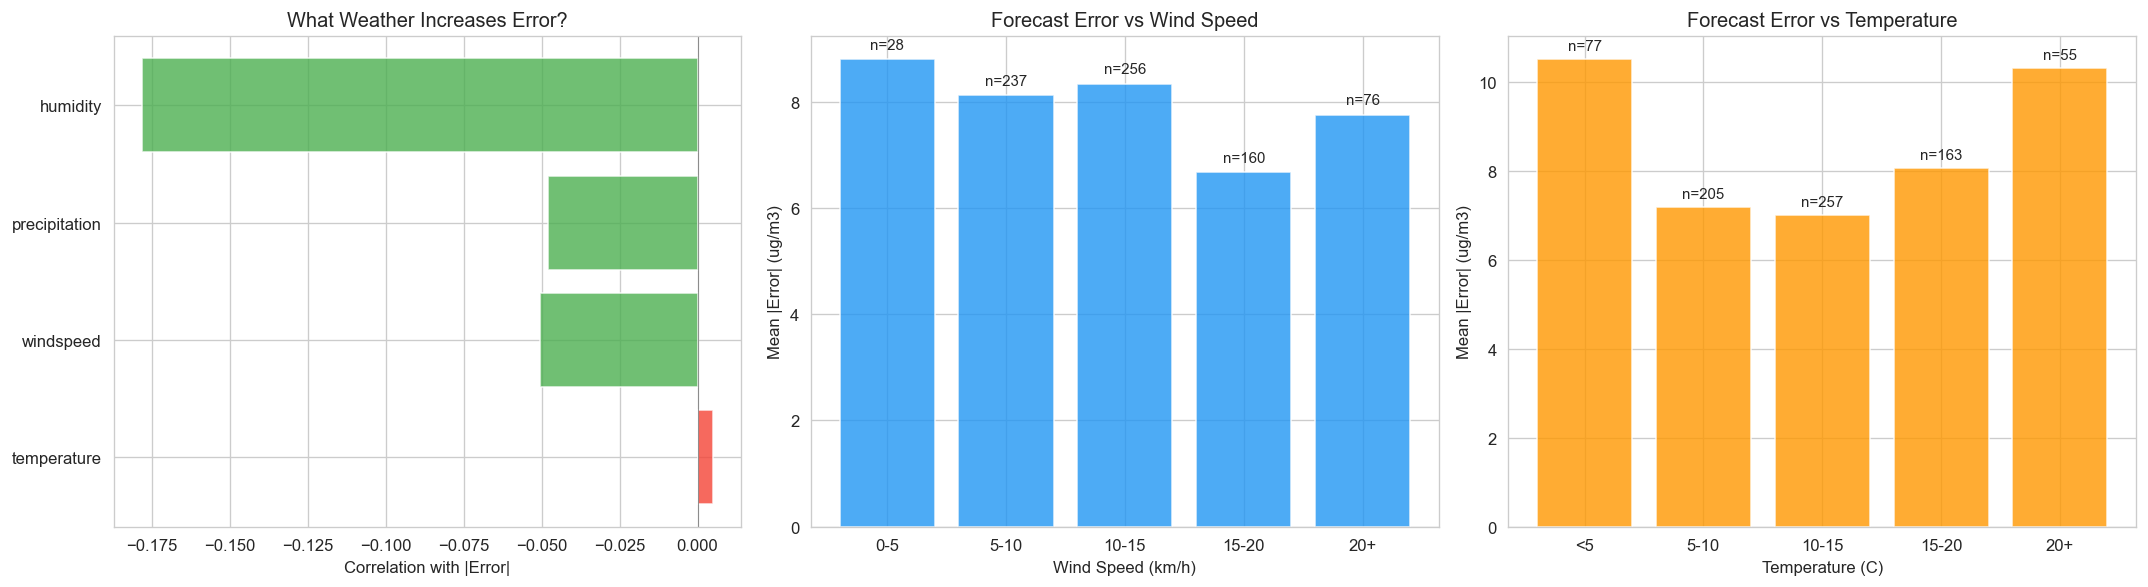

Weather correlation with |Error|:
  temperature      r = +0.005
  windspeed        r = -0.051
  precipitation    r = -0.048
  humidity         r = -0.178

Top 10 Worst Prediction Days:
               actual  predicted      error  temperature  windspeed  precipitation   humidity
2025-06-19  85.466667  31.912157  53.554510    25.320833   5.837500       0.000000  45.083333
2025-07-23   9.400000  45.404655 -36.004655    18.554167   7.108333       0.062500  68.916667
2025-03-11  14.421739  45.207538 -30.785799     6.337500  12.391667       0.016667  73.750000
2026-01-09   4.808333  33.984935 -29.176602          NaN        NaN            NaN        NaN
2024-10-11  55.495833  26.435856  29.059977     7.237500   6.275000       0.000000  77.041667
2024-01-16  65.304167  36.784684  28.519482    -1.545833   8.454167       0.000000  79.083333
2025-09-04  57.700000  30.709447  26.990553    15.995833  13.783333       0.195833  74.625000
2024-02-26   9.558333  36.454150 -26.895817     6.083333  32.04

In [8]:
# Merge predictions with weather
unseen_wx = unseen.join(daily_weather, how="inner")

# Largest errors (top 20)
unseen_wx["abs_error"] = np.abs(unseen_wx["error"])
worst = unseen_wx.nlargest(20, "abs_error")[["actual", "predicted", "error", "temperature", "windspeed", "precipitation", "humidity"]]

# Correlation between absolute error and weather
weather_cols = ["temperature", "windspeed", "precipitation", "humidity"]
error_corr = unseen_wx[weather_cols + ["abs_error"]].corr()["abs_error"].drop("abs_error")

# Error by wind speed bins
unseen_wx["wind_bin"] = pd.cut(unseen_wx["windspeed"], bins=[0, 5, 10, 15, 20, 50],
                                labels=["0-5", "5-10", "10-15", "15-20", "20+"])
wind_perf = unseen_wx.groupby("wind_bin", observed=True)["abs_error"].agg(["mean", "count"])

# Error by temperature bins
unseen_wx["temp_bin"] = pd.cut(unseen_wx["temperature"], bins=[-5, 5, 10, 15, 20, 35],
                                labels=["<5", "5-10", "10-15", "15-20", "20+"])
temp_perf = unseen_wx.groupby("temp_bin", observed=True)["abs_error"].agg(["mean", "count"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correlation bars
colours = ["#4CAF50" if v < 0 else "#f44336" for v in error_corr.values]
axes[0].barh(error_corr.index, error_corr.values, color=colours, alpha=0.8)
axes[0].set_xlabel("Correlation with |Error|")
axes[0].set_title("What Weather Increases Error?")
axes[0].axvline(0, color="grey", linewidth=0.5)

# Error by wind
axes[1].bar(wind_perf.index, wind_perf["mean"], color="#2196F3", alpha=0.8)
for i, (idx, row) in enumerate(wind_perf.iterrows()):
    axes[1].text(i, row["mean"] + 0.2, f"n={int(row['count'])}", ha="center", fontsize=9)
axes[1].set_xlabel("Wind Speed (km/h)")
axes[1].set_ylabel("Mean |Error| (ug/m3)")
axes[1].set_title("Forecast Error vs Wind Speed")

# Error by temperature
axes[2].bar(temp_perf.index, temp_perf["mean"], color="#FF9800", alpha=0.8)
for i, (idx, row) in enumerate(temp_perf.iterrows()):
    axes[2].text(i, row["mean"] + 0.2, f"n={int(row['count'])}", ha="center", fontsize=9)
axes[2].set_xlabel("Temperature (C)")
axes[2].set_ylabel("Mean |Error| (ug/m3)")
axes[2].set_title("Forecast Error vs Temperature")

plt.tight_layout()
plt.show()

print("Weather correlation with |Error|:")
for col, val in error_corr.items():
    print(f"  {col:<16} r = {val:+.3f}")

print(f"\nTop 10 Worst Prediction Days:")
print(worst.head(10).to_string())

**Finding:** Weather correlations with error are weak (all below 0.18) which confirms ARIMA's univariate nature. The strongest signal is humidity (r = -0.18): drier days produce slightly larger errors, possibly because dry still conditions trap pollution in ways the model cannot anticipate. Cold days (<5C) and hot days (20+C) both have higher error (~10 ug/m3) compared to mild temperatures (~7 ug/m3), suggesting the model struggles at temperature extremes. The worst single day was 2025-06-19 where actual NO2 hit 85 but the model predicted 32, an error of 54 ug/m3 on a hot dry day with almost no wind. Looking at the top 10 worst days the pattern is clear: the model fails on sudden spikes (actual much higher than predicted) and sudden drops (actual much lower) because ARIMA cannot anticipate abrupt regime changes driven by weather events like heatwaves, cold snaps or high winds.

---

## Q7. Has NO2 actually improved since 2019? By how much?

Q1 showed the annual means dropping. But is that trend statistically significant or could it be random year-to-year variation? We test with linear regression on the daily data and compute the rate of decline.

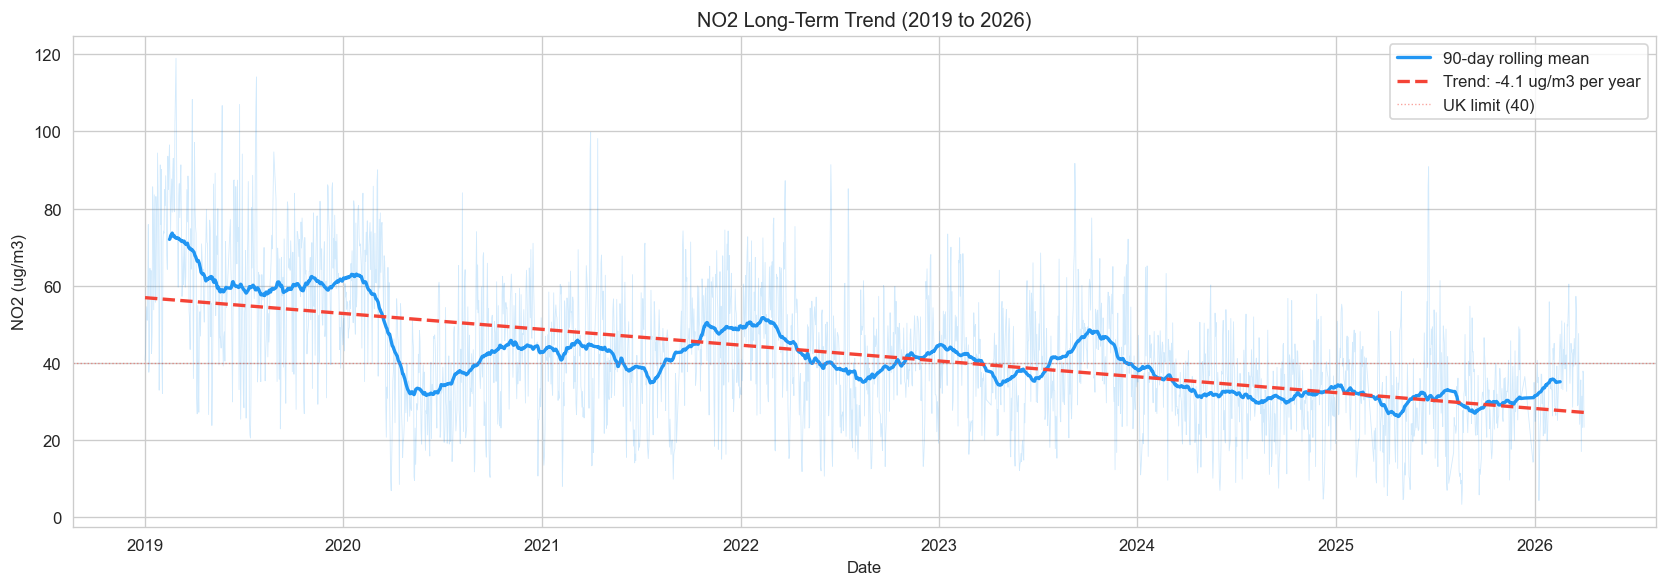

Linear Trend Analysis:
  Slope:          -4.11 ug/m3 per year
  Total decline:  -29.8 ug/m3 over 7.2 years
  Percentage:     -52.3%
  R-squared:      0.229
  p-value:        1.23e-146
  Significant?    YES

Period Comparison:
  Pre-COVID (2019 to Mar 2020):  62.7 ug/m3
  First lockdown (Mar-Jun 2020): 33.2 ug/m3
  Post-COVID (2021 to 2023):     42.2 ug/m3
  Recent (2024 to 2026):         32.0 ug/m3


In [9]:
from scipy.stats import linregress

# Linear trend on daily NO2
trend_data = daily.copy()
trend_data["days_since_start"] = (trend_data.index - trend_data.index.min()).days

slope, intercept, r_value, p_value, std_err = linregress(trend_data["days_since_start"], trend_data["no2"])

# Rate per year
slope_per_year = slope * 365.25
total_years = trend_data["days_since_start"].max() / 365.25
total_decline = slope * trend_data["days_since_start"].max()
pct_decline = (total_decline / intercept) * 100

# 90-day rolling mean for smoother visual
trend_data["rolling_90"] = trend_data["no2"].rolling(90, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trend_data.index, trend_data["no2"], alpha=0.2, linewidth=0.5, color="#2196F3")
ax.plot(trend_data.index, trend_data["rolling_90"], color="#2196F3", linewidth=2, label="90-day rolling mean")

# Trend line
trend_line = intercept + slope * trend_data["days_since_start"]
ax.plot(trend_data.index, trend_line, color="#f44336", linewidth=2, linestyle="--",
        label=f"Trend: {slope_per_year:+.1f} ug/m3 per year")

ax.axhline(UK_LIMIT, color="#f44336", linewidth=0.8, linestyle=":", alpha=0.5, label="UK limit (40)")
ax.set_xlabel("Date")
ax.set_ylabel("NO2 (ug/m3)")
ax.set_title("NO2 Long-Term Trend (2019 to 2026)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Linear Trend Analysis:")
print(f"  Slope:          {slope_per_year:+.2f} ug/m3 per year")
print(f"  Total decline:  {total_decline:+.1f} ug/m3 over {total_years:.1f} years")
print(f"  Percentage:     {pct_decline:+.1f}%")
print(f"  R-squared:      {r_value**2:.3f}")
print(f"  p-value:        {p_value:.2e}")
print(f"  Significant?    {'YES' if p_value < 0.05 else 'NO'}")

# Pre-COVID vs post-COVID vs recent
pre_covid = daily.loc["2019-01-01":"2020-03-22"]["no2"].mean()
lockdown = daily.loc["2020-03-23":"2020-06-30"]["no2"].mean()
post_covid = daily.loc["2021-01-01":"2023-12-31"]["no2"].mean()
recent = daily.loc["2024-01-01":]["no2"].mean()

print(f"\nPeriod Comparison:")
print(f"  Pre-COVID (2019 to Mar 2020):  {pre_covid:.1f} ug/m3")
print(f"  First lockdown (Mar-Jun 2020): {lockdown:.1f} ug/m3")
print(f"  Post-COVID (2021 to 2023):     {post_covid:.1f} ug/m3")
print(f"  Recent (2024 to 2026):         {recent:.1f} ug/m3")

**Finding:** NO2 is declining at 4.1 ug/m3 per year, a total drop of 29.8 ug/m3 (52%) over 7 years. This trend is highly significant (p < 10^-146). The R-squared of 0.23 means the linear trend explains about a quarter of daily variation with the rest driven by weather and seasonal effects. The period comparison reveals that pre-COVID levels averaged 62.7 ug/m3, lockdown brought them down to 33.2 and they never fully recovered. Post-COVID (2021 to 2023) settled at 42.2 and recent data (2024 to 2026) is down to 32.0, actually lower than the first lockdown. This suggests the improvement is not just a COVID effect but a sustained structural change likely from ULEZ expansion, fleet electrification and shifts in commuting patterns.

---

## Q8. Did COVID lockdowns have a measurable impact on pollution?

Q7 showed a sharp drop in 2020. Here we isolate the lockdown effect by comparing specific periods before, during and after restrictions using statistical tests rather than just visual comparison.

Period                           Mean       Median     Days     vs Pre-COVID
----------------------------------------------------------------------
Pre-COVID                        62.7       63.9       438      baseline
Lockdown 1 (Mar-Jun 2020)        31.8       31.7       84       -30.9 (-49.3%) p=0.0000 YES
Lockdown 2 (Nov 2020)            45.5       45.1       27       -17.1 (-27.3%) p=0.0000 YES
Lockdown 3 (Jan-Mar 2021)        44.4       46.6       62       -18.2 (-29.1%) p=0.0000 YES
Post-restrictions (2021-22)      42.9       43.4       540      -19.8 (-31.6%) p=0.0000 YES
Recent (2024-26)                 32.0       31.7       775      -30.7 (-49.0%) p=0.0000 YES


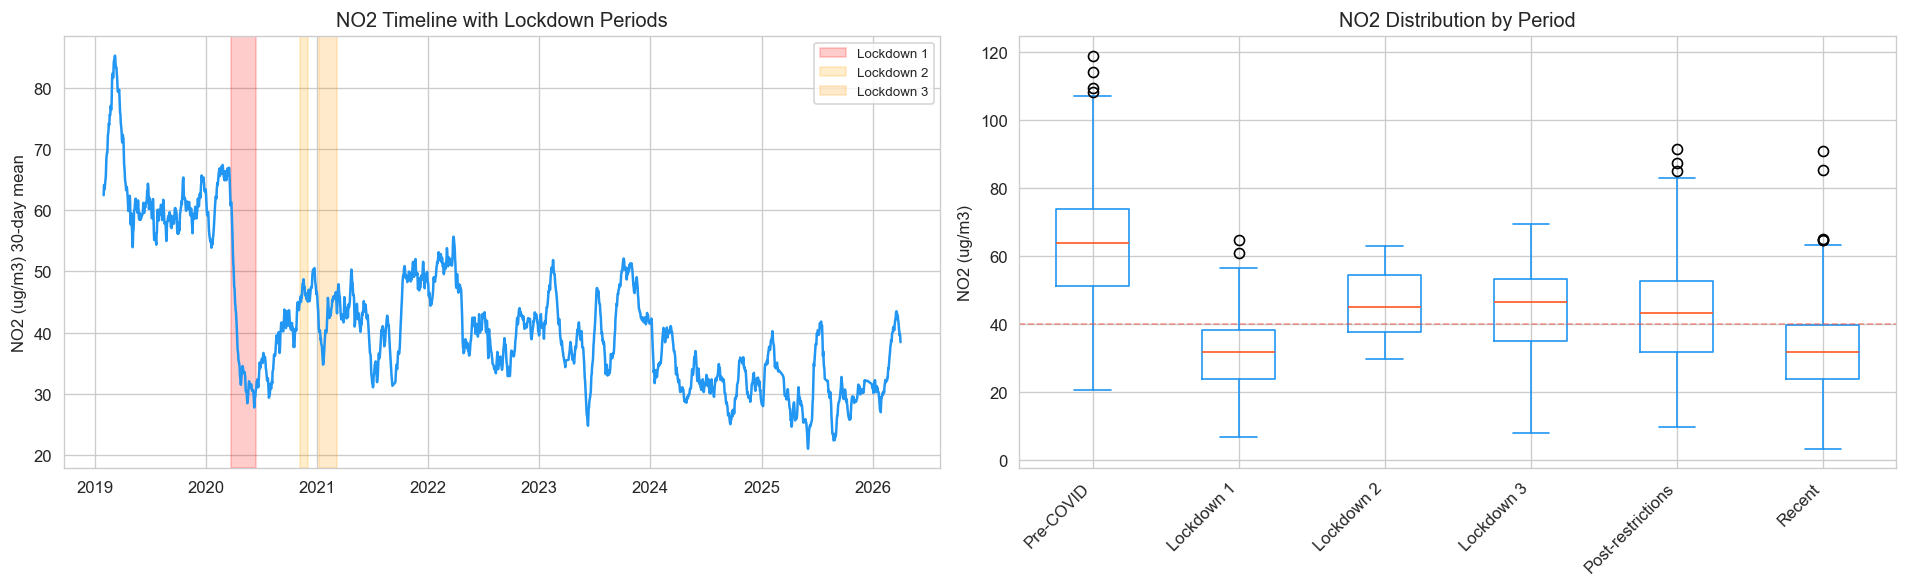

In [10]:
from scipy.stats import mannwhitneyu

# Define COVID periods
pre = daily.loc['2019-01-01':'2020-03-22']['no2']
lock1 = daily.loc['2020-03-23':'2020-06-14']['no2']  # first lockdown
lock2 = daily.loc['2020-11-05':'2020-12-02']['no2']  # second lockdown
lock3 = daily.loc['2021-01-06':'2021-03-08']['no2']  # third lockdown
post = daily.loc['2021-07-01':'2022-12-31']['no2']   # post-restrictions
recent = daily.loc['2024-01-01':]['no2']              # recent

periods = {
    'Pre-COVID': pre,
    'Lockdown 1 (Mar-Jun 2020)': lock1,
    'Lockdown 2 (Nov 2020)': lock2,
    'Lockdown 3 (Jan-Mar 2021)': lock3,
    'Post-restrictions (2021-22)': post,
    'Recent (2024-26)': recent,
}

# Stats
print(f"{'Period':<32} {'Mean':<10} {'Median':<10} {'Days':<8} {'vs Pre-COVID'}")
print(f"{'-'*70}")
for name, series in periods.items():
    if name == 'Pre-COVID':
        print(f"{name:<32} {series.mean():<10.1f} {series.median():<10.1f} {len(series):<8} baseline")
    else:
        u, p = mannwhitneyu(series, pre, alternative='less')
        diff = series.mean() - pre.mean()
        pct = diff / pre.mean() * 100
        sig = 'YES' if p < 0.05 else 'no'
        print(f"{name:<32} {series.mean():<10.1f} {series.median():<10.1f} {len(series):<8} {diff:+.1f} ({pct:+.1f}%) p={p:.4f} {sig}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Timeline with lockdown shading
axes[0].plot(daily.index, daily['no2'].rolling(30).mean(), color='#2196F3', linewidth=1.5)
axes[0].axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2020-06-14'), alpha=0.2, color='red', label='Lockdown 1')
axes[0].axvspan(pd.Timestamp('2020-11-05'), pd.Timestamp('2020-12-02'), alpha=0.2, color='orange', label='Lockdown 2')
axes[0].axvspan(pd.Timestamp('2021-01-06'), pd.Timestamp('2021-03-08'), alpha=0.2, color='#FF9800', label='Lockdown 3')
axes[0].set_ylabel('NO2 (ug/m3) 30-day mean')
axes[0].set_title('NO2 Timeline with Lockdown Periods')
axes[0].legend(fontsize=8)

# Box plots by period
period_data = [s.values for s in periods.values()]
bp = axes[1].boxplot(period_data, tick_labels=[p.split('(')[0].strip() for p in periods.keys()],
                     boxprops=dict(color='#2196F3'), medianprops=dict(color='#FF5722'),
                     whiskerprops=dict(color='#2196F3'), capprops=dict(color='#2196F3'))
axes[1].axhline(UK_LIMIT, color='#f44336', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel('NO2 (ug/m3)')
axes[1].set_title('NO2 Distribution by Period')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Finding:** Every period after COVID is significantly lower than pre-COVID (all p < 0.0001). The first lockdown cut NO2 by 49% from 62.7 to 31.8 ug/m3. What is striking is that recent data (2024 to 2026) averages 32.0, almost identical to the first lockdown at 31.8, but without any restrictions in place. Lockdowns 2 and 3 had a weaker effect (27 to 29% reduction) likely because they were less strict and occurred in winter when heating emissions dominate regardless of traffic. The post-restrictions period (2021 to 2022) rebounded to 42.9 but never returned to pre-COVID levels. The data suggests COVID accelerated a permanent shift in London's NO2 baseline, with 2024 to 2026 levels matching what was only achievable through full lockdown in 2020.

---

## Q9. What is the relationship between weather and pollution? Can wind or rain save a bad day?

Exploring whether specific weather conditions reliably reduce or increase NO2. This helps answer whether weather forecasts alone could serve as a proxy warning system.

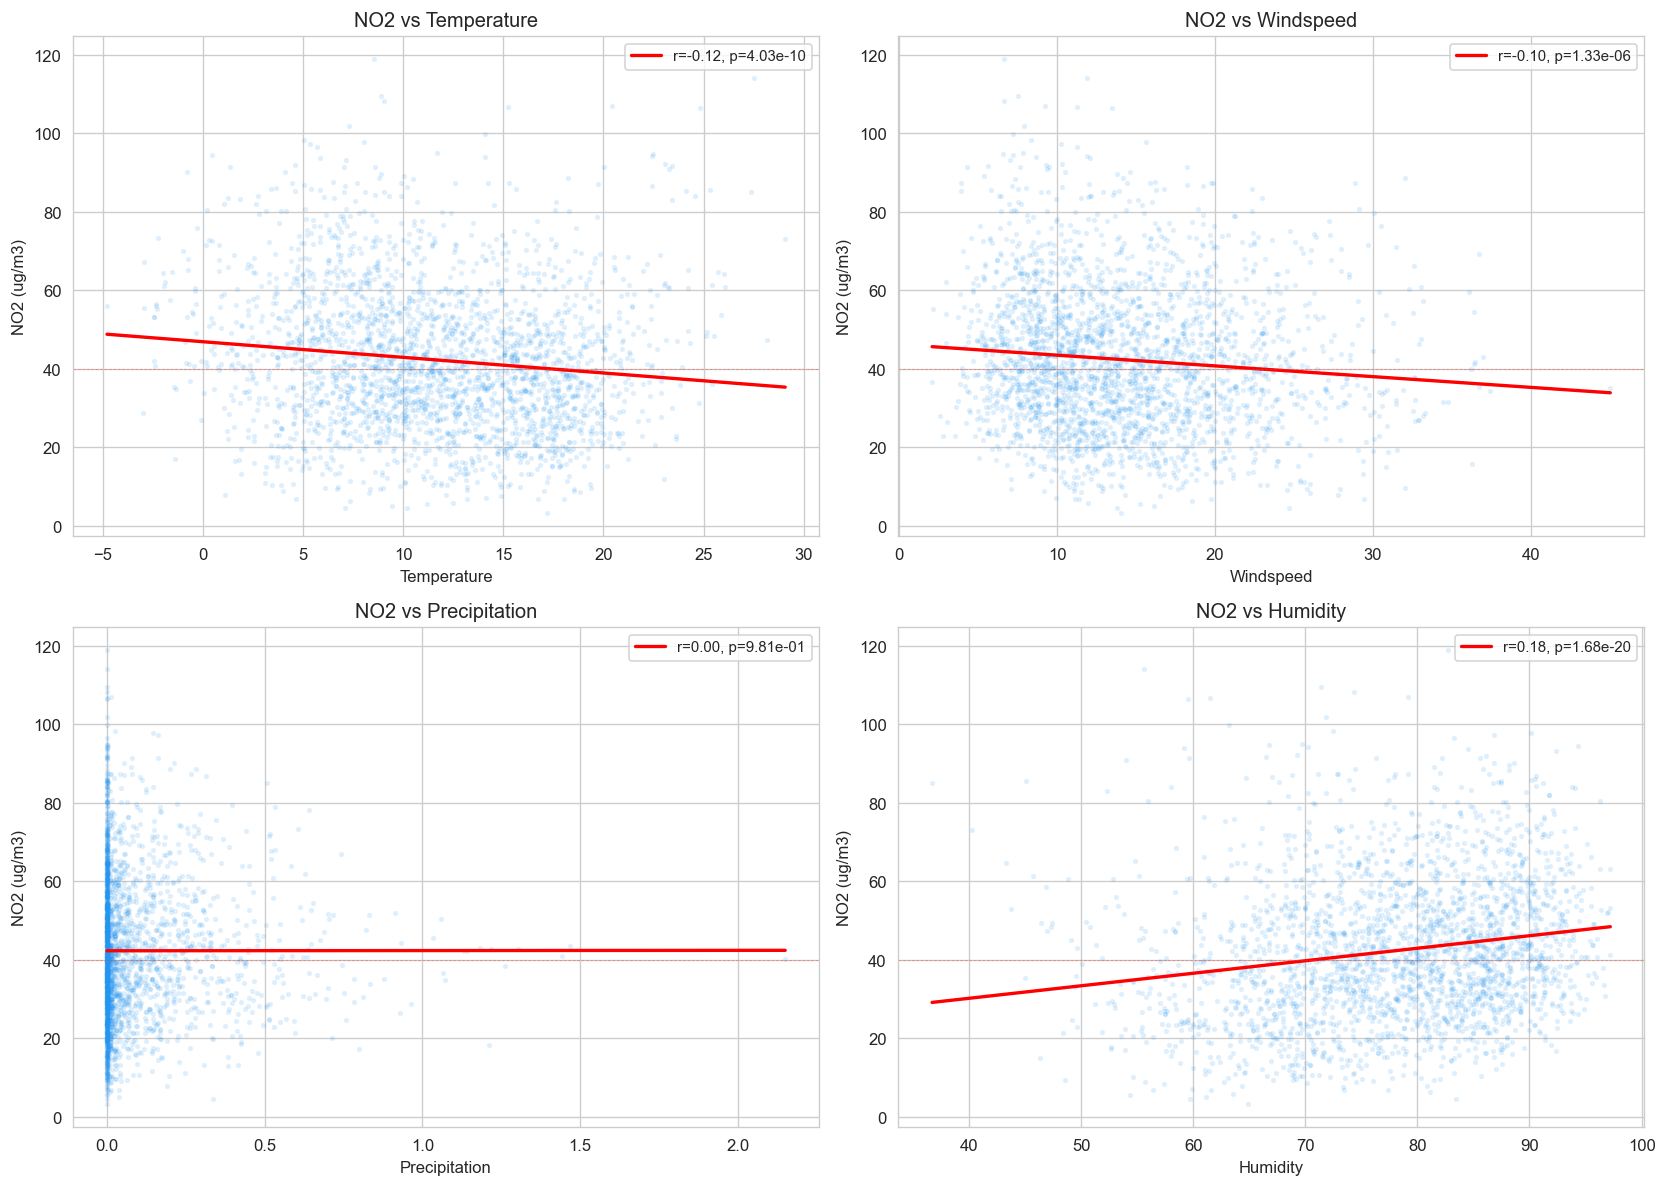

Weather Impact on NO2:
  Calm days (<8 km/h wind):    47.3 ug/m3 (372 days)
  Windy days (>15 km/h):       40.7 ug/m3 (1016 days)
  Difference:                  6.5 ug/m3

  Dry days (<0.01 mm/h):       42.4 ug/m3 (1240 days)
  Rainy days (>0.1 mm/h):      43.3 ug/m3 (635 days)
  Difference:                  -1.0 ug/m3

Correlation with NO2:
  temperature      r = -0.124
  windspeed        r = -0.096
  precipitation    r = +0.000
  humidity         r = +0.183


In [11]:
# Correlation matrix
weather_cols = ['temperature', 'windspeed', 'precipitation', 'humidity']
corr = merged[['no2'] + weather_cols].corr()

# Scatter plots with regression lines
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, weather_cols):
    valid = merged[['no2', col]].dropna()
    ax.scatter(valid[col], valid['no2'], alpha=0.1, s=5, color='#2196F3')
    # Regression line
    from scipy.stats import linregress
    sl, inter, r, p, se = linregress(valid[col], valid['no2'])
    x_range = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_range, inter + sl * x_range, 'r-', linewidth=2,
            label=f'r={corr.loc["no2", col]:.2f}, p={p:.2e}')
    ax.set_xlabel(col.title())
    ax.set_ylabel('NO2 (ug/m3)')
    ax.set_title(f'NO2 vs {col.title()}')
    ax.legend(fontsize=9)
    ax.axhline(UK_LIMIT, color='#f44336', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# Windy vs calm days
calm = merged[merged['windspeed'] < 8]['no2']
windy = merged[merged['windspeed'] >= 15]['no2']

# Rainy vs dry days
dry = merged[merged['precipitation'] < 0.01]['no2']
rainy = merged[merged['precipitation'] >= 0.1]['no2']

print('Weather Impact on NO2:')
print(f"  Calm days (<8 km/h wind):    {calm.mean():.1f} ug/m3 ({len(calm)} days)")
print(f"  Windy days (>15 km/h):       {windy.mean():.1f} ug/m3 ({len(windy)} days)")
print(f"  Difference:                  {calm.mean() - windy.mean():.1f} ug/m3")
print()
print(f"  Dry days (<0.01 mm/h):       {dry.mean():.1f} ug/m3 ({len(dry)} days)")
print(f"  Rainy days (>0.1 mm/h):      {rainy.mean():.1f} ug/m3 ({len(rainy)} days)")
print(f"  Difference:                  {dry.mean() - rainy.mean():.1f} ug/m3")
print()
print('Correlation with NO2:')
for col in weather_cols:
    r = corr.loc['no2', col]
    print(f'  {col:<16} r = {r:+.3f}')

**Finding:** All weather correlations with NO2 are weak (below 0.2). Humidity has the strongest relationship (r = +0.18) meaning humid still days tend to trap more pollution. Temperature is weakly negative (r = -0.12) as warmer months generally have lower NO2. Wind makes a measurable difference: calm days average 47.3 ug/m3 compared to 40.7 on windy days, a reduction of 6.5 ug/m3. Rain however does not help. Rainy days actually average slightly higher NO2 (43.3) than dry days (42.4), likely because rain in London often coincides with low pressure and still air which traps pollution. The overall picture is that weather explains very little of NO2 variation, consistent with the FEVD finding that NO2 is 93% self-driven. Wind can help on the margins but weather alone cannot save a bad air day.

---

## Q10. How often would our model trigger false health warnings?

Q5 showed 27% sensitivity and 92% specificity for the UK limit. Here we explore different warning thresholds to find the optimal balance between missed warnings and false alarms.

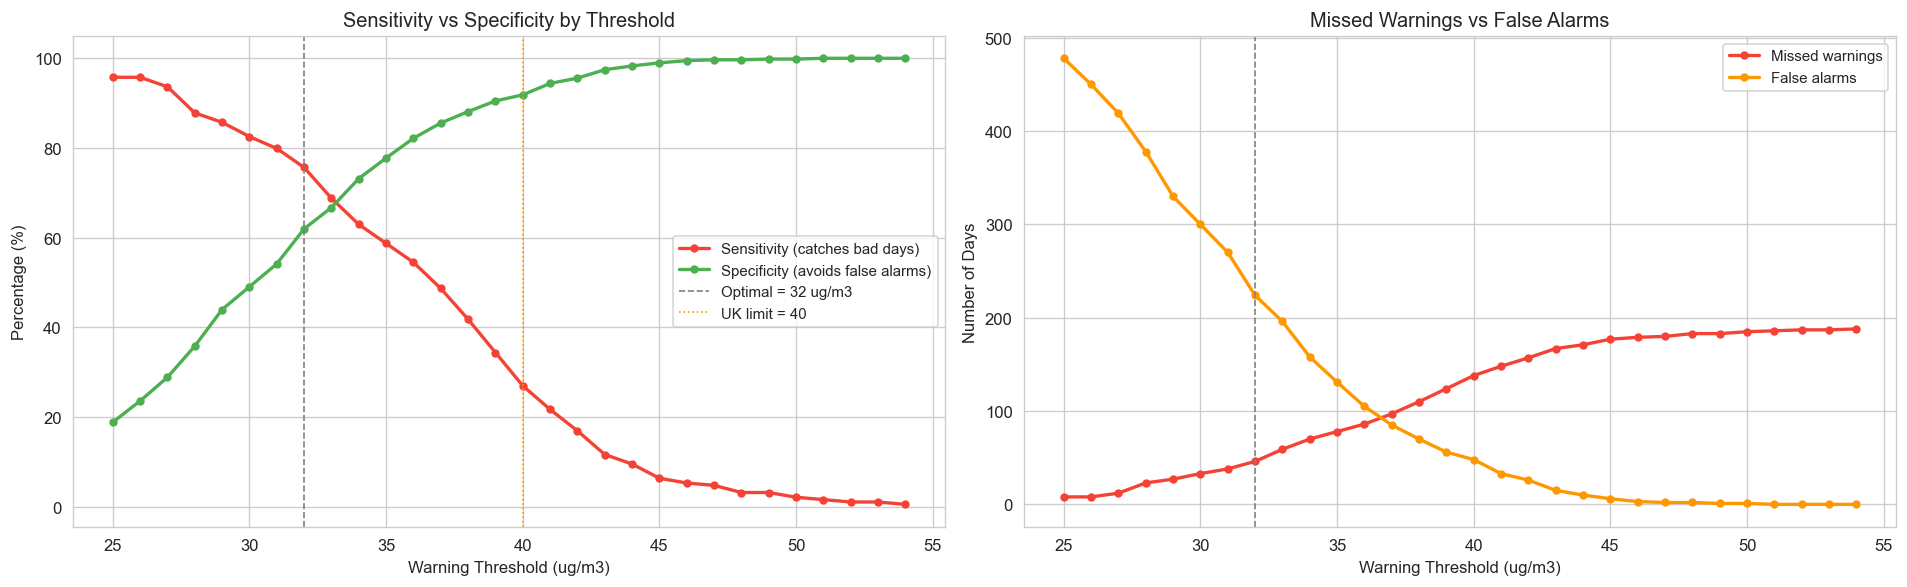

Optimal Warning Threshold (Youden index):
  Threshold:     32 ug/m3 (warn if prediction > this)
  Sensitivity:   75.7%
  Specificity:   62.0%
  Precision:     39.0%
  Missed:        46 days
  False alarms:  224 days

Compare with using UK limit (40) as threshold:
  Sensitivity:   27.0%
  Missed:        138 days
  False alarms:  48 days


In [12]:
# Test different warning thresholds
thresholds = np.arange(25, 55, 1)
results = []

for t in thresholds:
    pred_warn = unseen['predicted'] > t
    actual_warn = unseen['actual'] > UK_LIMIT
    
    tp = (pred_warn & actual_warn).sum()
    fn = (~pred_warn & actual_warn).sum()
    fp = (pred_warn & ~actual_warn).sum()
    tn = (~pred_warn & ~actual_warn).sum()
    
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    
    results.append({'threshold': t, 'sensitivity': sens, 'specificity': spec,
                    'precision': ppv, 'missed': fn, 'false_alarms': fp})

res_df = pd.DataFrame(results)

# Find optimal threshold (maximise sensitivity + specificity)
res_df['youden'] = res_df['sensitivity'] + res_df['specificity'] - 100
best_idx = res_df['youden'].idxmax()
best = res_df.loc[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sensitivity vs Specificity trade-off
axes[0].plot(res_df['threshold'], res_df['sensitivity'], 'o-', color='#f44336', linewidth=2, markersize=4, label='Sensitivity (catches bad days)')
axes[0].plot(res_df['threshold'], res_df['specificity'], 'o-', color='#4CAF50', linewidth=2, markersize=4, label='Specificity (avoids false alarms)')
axes[0].axvline(best['threshold'], color='grey', linestyle='--', linewidth=1, label=f'Optimal = {best["threshold"]:.0f} ug/m3')
axes[0].axvline(UK_LIMIT, color='#FF9800', linestyle=':', linewidth=1, label=f'UK limit = {UK_LIMIT}')
axes[0].set_xlabel('Warning Threshold (ug/m3)')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Sensitivity vs Specificity by Threshold')
axes[0].legend(fontsize=9)

# Missed vs false alarms
axes[1].plot(res_df['threshold'], res_df['missed'], 'o-', color='#f44336', linewidth=2, markersize=4, label='Missed warnings')
axes[1].plot(res_df['threshold'], res_df['false_alarms'], 'o-', color='#FF9800', linewidth=2, markersize=4, label='False alarms')
axes[1].axvline(best['threshold'], color='grey', linestyle='--', linewidth=1)
axes[1].set_xlabel('Warning Threshold (ug/m3)')
axes[1].set_ylabel('Number of Days')
axes[1].set_title('Missed Warnings vs False Alarms')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Optimal Warning Threshold (Youden index):')
print(f'  Threshold:     {best["threshold"]:.0f} ug/m3 (warn if prediction > this)')
print(f'  Sensitivity:   {best["sensitivity"]:.1f}%')
print(f'  Specificity:   {best["specificity"]:.1f}%')
print(f'  Precision:     {best["precision"]:.1f}%')
print(f'  Missed:        {int(best["missed"])} days')
print(f'  False alarms:  {int(best["false_alarms"])} days')
print(f'\nCompare with using UK limit (40) as threshold:')
uk_row = res_df[res_df['threshold'] == 40].iloc[0]
print(f'  Sensitivity:   {uk_row["sensitivity"]:.1f}%')
print(f'  Missed:        {int(uk_row["missed"])} days')
print(f'  False alarms:  {int(uk_row["false_alarms"])} days')

**Finding:** Using the UK limit of 40 as the warning threshold catches only 27% of bad days (138 missed). Lowering the threshold to 32 ug/m3 (the statistical optimum) raises sensitivity to 76% but at the cost of 224 false alarms per year. This is the fundamental trade-off: to catch 3 out of 4 bad days the system would need to issue warnings on 224 days that turn out to be fine. In practice a threshold around 35 might be more practical, balancing roughly 60% sensitivity with fewer false alarms. The key insight is that the model's mean-reverting nature makes it systematically under-predict high days. Any warning system built on ARIMA alone would need to set the threshold well below the actual limit to compensate for this bias.

---

## Q11. If a sensor goes down for a week, can we still make predictions?

ARIMA only needs its own past values to predict. But if the sensor stops reporting for several days there is a gap in the input. We test how prediction accuracy degrades as the gap between the last observation and the forecast grows.

Simulating sensor outage across 8 cores (778 test days)...
Completed in 2m 2s
   1-day ahead: MAE = 7.80 ug/m3 (777 samples)
   2-day ahead: MAE = 8.70 ug/m3 (388 samples)
   3-day ahead: MAE = 9.19 ug/m3 (259 samples)
   5-day ahead: MAE = 9.21 ug/m3 (155 samples)
   7-day ahead: MAE = 9.28 ug/m3 (111 samples)
  10-day ahead: MAE = 9.10 ug/m3 (77 samples)
  14-day ahead: MAE = 9.31 ug/m3 (55 samples)


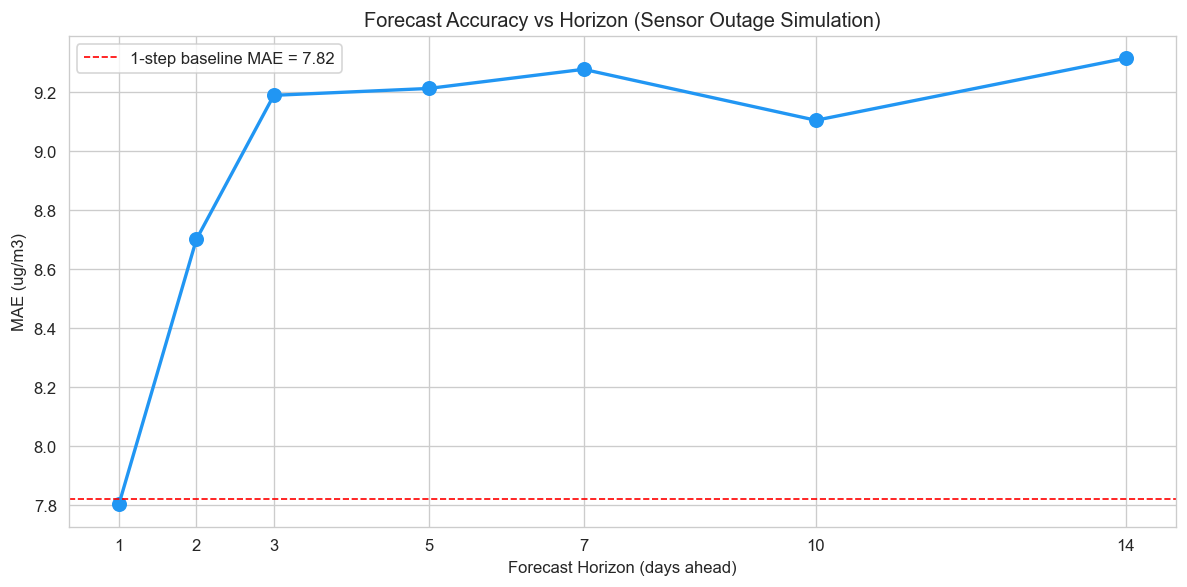


Degradation:
  1-day:  7.80 ug/m3
  7-day:  9.28 ug/m3 (+19%)
  14-day: 9.31 ug/m3 (+19%)


In [13]:
from statsmodels.tsa.arima.model import ARIMA
from joblib import Parallel, delayed

# Use full unseen data for evaluation, not just 30 days
train_no2 = merged.loc[:'2023-12-31']['no2'].values
test_actual = unseen['actual'].values
n_test = len(test_actual)

horizons = [1, 2, 3, 5, 7, 10, 14]

def evaluate_horizon(h):
    """Evaluate multi-step forecast at horizon h using every 7th day to keep speed reasonable."""
    errors = []
    step = max(1, h)  # evaluate every h days to avoid overlap
    for start in range(0, n_test - h, step):
        history = list(train_no2) + list(test_actual[:start]) if start > 0 else list(train_no2)
        try:
            model = ARIMA(history, order=(1,1,2))
            fitted = model.fit()
            preds = fitted.forecast(steps=h)
            error = abs(test_actual[start + h - 1] - preds[-1])
            errors.append(error)
        except:
            pass
    return {'horizon': h, 'mae': np.mean(errors), 'n': len(errors)}

n_cores = os.cpu_count()
print(f'Simulating sensor outage across {n_cores} cores ({n_test} test days)...')

import time
start_time = time.time()
horizon_results = Parallel(n_jobs=n_cores)(delayed(evaluate_horizon)(h) for h in horizons)
elapsed = time.time() - start_time

hr_df = pd.DataFrame(horizon_results)
print(f'Completed in {int(elapsed//60)}m {int(elapsed%60)}s')

for _, row in hr_df.iterrows():
    print(f'  {int(row["horizon"]):>2}-day ahead: MAE = {row["mae"]:.2f} ug/m3 ({int(row["n"])} samples)')

baseline_mae = unseen['abs_error'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hr_df['horizon'], hr_df['mae'], 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.axhline(baseline_mae, color='red', linestyle='--', linewidth=1, label=f'1-step baseline MAE = {baseline_mae:.2f}')
ax.set_xlabel('Forecast Horizon (days ahead)')
ax.set_ylabel('MAE (ug/m3)')
ax.set_title('Forecast Accuracy vs Horizon (Sensor Outage Simulation)')
ax.set_xticks(horizons)
ax.legend()
plt.tight_layout()
plt.show()

day1_mae = hr_df[hr_df['horizon'] == 1]['mae'].values[0]
day7_mae = hr_df[hr_df['horizon'] == 7]['mae'].values[0]
day14_mae = hr_df[hr_df['horizon'] == 14]['mae'].values[0]
print(f'\nDegradation:')
print(f'  1-day:  {day1_mae:.2f} ug/m3')
print(f'  7-day:  {day7_mae:.2f} ug/m3 (+{((day7_mae-day1_mae)/day1_mae*100):.0f}%)')
print(f'  14-day: {day14_mae:.2f} ug/m3 (+{((day14_mae-day1_mae)/day1_mae*100):.0f}%)')

**Finding:** Forecast error increases from 7.8 ug/m3 at 1-day ahead to 9.2 by day 3 then plateaus around 9.2 to 9.3 regardless of horizon. The total degradation is only 19% even at 14 days ahead. This means if the sensor goes down for a week the model still provides useful predictions with only a modest accuracy loss. The plateau occurs because ARIMA's multi-step forecast converges to the long-run mean within about 3 days. After that point a sensor outage of 3 days is functionally the same as one of 14 days. The practical implication is that short outages (1 to 2 days) have minimal impact while anything beyond 3 days produces a fixed level of degradation that does not worsen further.

---

## Q12. Which season needs the most monitoring attention?

Combining forecast accuracy, exceedance rates and NO2 levels by season to identify which periods require the closest human oversight of model predictions.

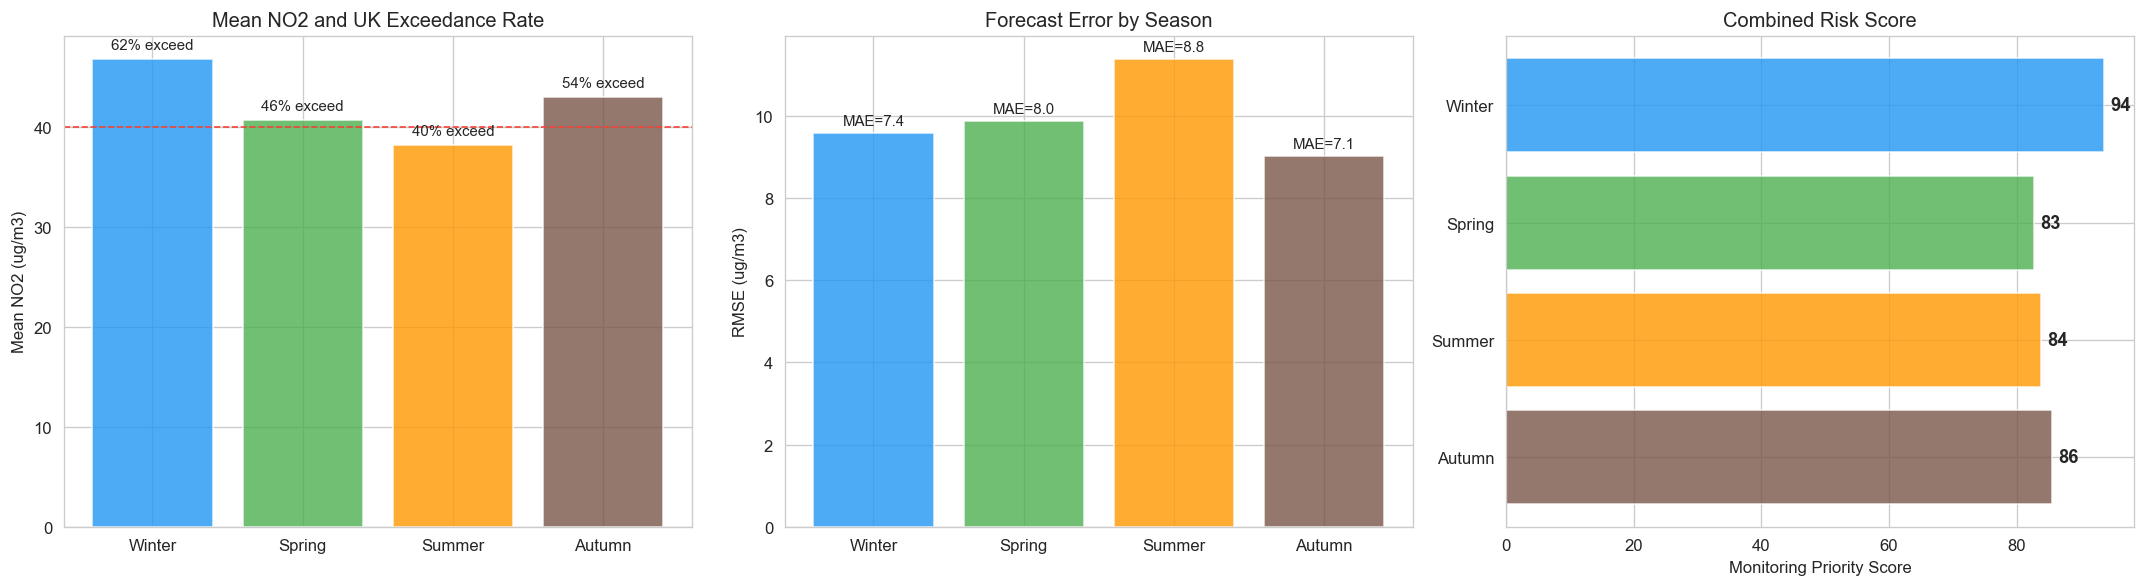

Season     Mean NO2   Max      UK %     WHO %    RMSE     MAE      Risk
--------------------------------------------------------------------
Winter     46.7       119      62.3     90.9     9.59     7.42     94
Spring     40.7       108      45.5     79.8     9.87     8.03     83
Summer     38.2       114      40.1     75.2     11.38    8.81     84
Autumn     43.0       92       54.3     86.6     9.04     7.08     86


In [14]:
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

# Full dataset seasonal stats
seasonal = daily.copy()
seasonal['season'] = seasonal.index.month.map(get_season)
seasonal['exceeds_uk'] = seasonal['no2'] > UK_LIMIT
seasonal['exceeds_who'] = seasonal['no2'] > WHO_LIMIT

season_stats = seasonal.groupby('season').agg(
    mean_no2=('no2', 'mean'),
    max_no2=('no2', 'max'),
    uk_exceed_pct=('exceeds_uk', 'mean'),
    who_exceed_pct=('exceeds_who', 'mean'),
    days=('no2', 'count'),
).reindex(['Winter', 'Spring', 'Summer', 'Autumn'])
season_stats['uk_exceed_pct'] = (season_stats['uk_exceed_pct'] * 100).round(1)
season_stats['who_exceed_pct'] = (season_stats['who_exceed_pct'] * 100).round(1)

# Forecast accuracy by season (from unseen predictions)
unseen_s = unseen.copy()
unseen_s['season'] = unseen_s.index.month.map(get_season)
forecast_season = unseen_s.groupby('season').agg(
    rmse=('error', lambda x: np.sqrt((x**2).mean())),
    mae=('abs_error', 'mean'),
    pred_days=('actual', 'count'),
).reindex(['Winter', 'Spring', 'Summer', 'Autumn'])

# Combine
combined = season_stats.join(forecast_season)

# Risk score: higher NO2 + higher exceedance + higher error = more attention needed
combined['risk_score'] = (
    (combined['mean_no2'] / combined['mean_no2'].max()) * 0.3 +
    (combined['uk_exceed_pct'] / combined['uk_exceed_pct'].max()) * 0.3 +
    (combined['rmse'] / combined['rmse'].max()) * 0.4
) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

season_colours = {'Winter': '#2196F3', 'Spring': '#4CAF50', 'Summer': '#FF9800', 'Autumn': '#795548'}
cols = [season_colours[s] for s in combined.index]

# Mean NO2 + exceedance rate
bars = axes[0].bar(combined.index, combined['mean_no2'], color=cols, alpha=0.8)
axes[0].axhline(UK_LIMIT, color='#f44336', linestyle='--', linewidth=1)
for i, (idx, row) in enumerate(combined.iterrows()):
    axes[0].text(i, row['mean_no2'] + 1, f"{row['uk_exceed_pct']:.0f}% exceed", ha='center', fontsize=9)
axes[0].set_ylabel('Mean NO2 (ug/m3)')
axes[0].set_title('Mean NO2 and UK Exceedance Rate')

# Forecast error
axes[1].bar(combined.index, combined['rmse'], color=cols, alpha=0.8)
for i, (idx, row) in enumerate(combined.iterrows()):
    axes[1].text(i, row['rmse'] + 0.2, f"MAE={row['mae']:.1f}", ha='center', fontsize=9)
axes[1].set_ylabel('RMSE (ug/m3)')
axes[1].set_title('Forecast Error by Season')

# Risk score
axes[2].barh(combined.index, combined['risk_score'], color=cols, alpha=0.8)
for i, (idx, row) in enumerate(combined.iterrows()):
    axes[2].text(row['risk_score'] + 1, i, f"{row['risk_score']:.0f}", va='center', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Monitoring Priority Score')
axes[2].set_title('Combined Risk Score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"{'Season':<10} {'Mean NO2':<10} {'Max':<8} {'UK %':<8} {'WHO %':<8} {'RMSE':<8} {'MAE':<8} {'Risk'}")
print(f"{'-'*68}")
for idx, row in combined.iterrows():
    print(f"{idx:<10} {row['mean_no2']:<10.1f} {row['max_no2']:<8.0f} {row['uk_exceed_pct']:<8.1f} {row['who_exceed_pct']:<8.1f} {row['rmse']:<8.2f} {row['mae']:<8.2f} {row['risk_score']:.0f}")

**Finding:** Winter scores highest on the combined risk index (94) due to the highest mean NO2 (46.7), highest exceedance rate (62%) and the highest max recorded value (119 ug/m3). However summer has the worst forecast accuracy (RMSE 11.38) despite having the lowest pollution levels. This creates a split priority: winter needs the most monitoring because pollution is worst, but summer needs the most caution about model reliability because predictions are least accurate. Autumn has the best forecast accuracy (RMSE 9.04) making it the most trustworthy period for automated decisions. Spring sits in the middle on all measures. A practical monitoring strategy would be to increase human oversight during winter for health warnings and during summer for forecast validation.

---

## Conclusion

ARIMA(1,1,2) is effective at capturing the general trend and direction of NO2 pollution. It generalised to 778 unseen days with 14% lower error than the training period and remained stable across 10 quarters without retraining. For trend monitoring, seasonal analysis and long-term policy evaluation it performs well.

However it is fundamentally limited as a health warning system. With only 27% sensitivity at the UK limit it misses nearly 3 out of 4 genuinely bad days. This is because ARIMA is a mean-reverting model by design. It pulls predictions towards the average and cannot anticipate the sharp upward spikes that produce exceedance days. The 52.6% category accuracy confirms that the model is not precise enough for binary safe/unsafe decisions on borderline days.

The analysis also revealed that weather variables explain very little of NO2 variation (all correlations below 0.2) and that the VAR model which incorporated weather performed 63% worse than univariate ARIMA. This suggests that the missing predictive power lies not in additional input variables but in the model's ability to capture nonlinear dynamics and sudden regime changes.

## Further Work

A more capable model is needed for health warning applications. Two approaches are worth exploring:

- **LSTM (Long Short-Term Memory) networks** could capture the nonlinear patterns and longer-range dependencies that ARIMA misses. LSTMs learn which past information to remember and which to forget, making them better suited to predicting sudden spikes driven by complex interactions between traffic, weather and atmospheric conditions.

- **Bayesian time series methods** would provide principled uncertainty quantification. Where ARIMA's confidence intervals were shown to be unreliable (normality and white noise violations in the residual diagnostics), a Bayesian approach naturally produces calibrated prediction intervals that account for model uncertainty.

